In [23]:
import pandas as pd
df=pd.read_csv('/content/diabetes.csv')

In [24]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [25]:
df.shape

(768, 9)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [27]:
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [28]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [29]:
(df[["Pregnancies","Glucose","BloodPressure","SkinThickness",
"Insulin","BMI","DiabetesPedigreeFunction","Age","Outcome"]] == 0).sum()

,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,500


In [30]:
cols = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]

for col in cols:
    df[col] = df[col].replace(0, df[col].median())


In [31]:
(df[["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]] == 0).sum()


,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0


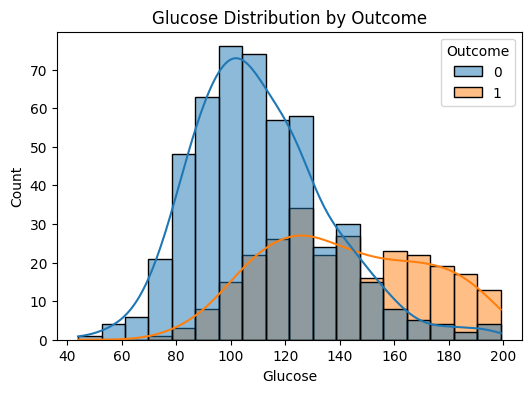

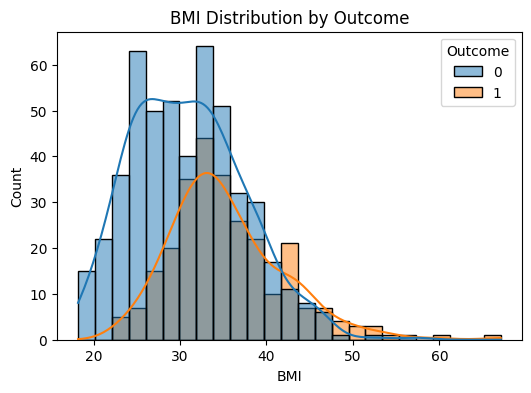

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.histplot(data=df, x="Glucose", hue="Outcome", kde=True)
plt.title("Glucose Distribution by Outcome")
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(data=df, x="BMI", hue="Outcome", kde=True)
plt.title("BMI Distribution by Outcome")
plt.show()



In [33]:
cols = ["Pregnancies","Glucose","BloodPressure","SkinThickness",
        "Insulin","BMI","DiabetesPedigreeFunction","Age"]

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col} : {len(outliers)} outliers")


Pregnancies : 4 outliers
Glucose : 0 outliers
BloodPressure : 14 outliers
SkinThickness : 35 outliers
Insulin : 49 outliers
BMI : 8 outliers
DiabetesPedigreeFunction : 29 outliers
Age : 9 outliers


In [34]:
x = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [35]:
print(x.shape)
print(y.shape)

(768, 8)
(768,)


In [36]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


In [38]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [39]:
from sklearn.neighbors import KNeighborsClassifier

accuracy = []

from sklearn.metrics import accuracy_score

for k in range(1,21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)

    y_pred = knn.predict(x_test)

    acc = accuracy_score(y_test, y_pred)
    accuracy.append(acc)

    print(f"K = {k}, Accuracy = {acc:.4f}")

K = 1, Accuracy = 0.7208
K = 2, Accuracy = 0.7273
K = 3, Accuracy = 0.7013
K = 4, Accuracy = 0.7078
K = 5, Accuracy = 0.7078
K = 6, Accuracy = 0.7208
K = 7, Accuracy = 0.6948
K = 8, Accuracy = 0.7273
K = 9, Accuracy = 0.6948
K = 10, Accuracy = 0.7208
K = 11, Accuracy = 0.7078
K = 12, Accuracy = 0.7273
K = 13, Accuracy = 0.7143
K = 14, Accuracy = 0.7273
K = 15, Accuracy = 0.7403
K = 16, Accuracy = 0.7403
K = 17, Accuracy = 0.7338
K = 18, Accuracy = 0.7532
K = 19, Accuracy = 0.7468
K = 20, Accuracy = 0.7532


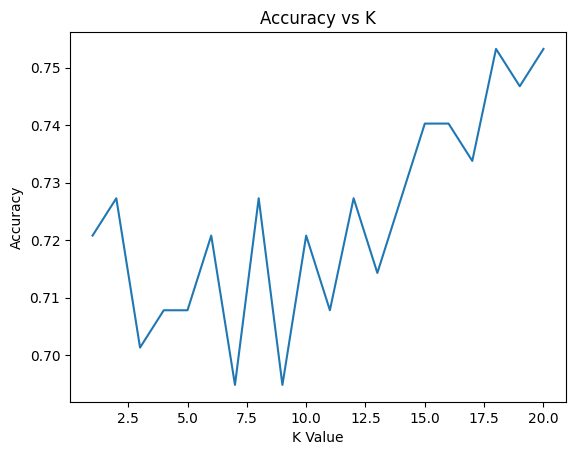

In [40]:
import matplotlib.pyplot as plt
plt.plot(range(1,21), accuracy)
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.show()

In [41]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=18)
knn.fit(x_train, y_train)


KNeighborsClassifier(n_neighbors=18)

In [42]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = knn.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.7532467532467533
[[87 13]
 [25 29]]
              precision    recall  f1-score   support

           0       0.78      0.87      0.82       100
           1       0.69      0.54      0.60        54

    accuracy                           0.75       154
   macro avg       0.73      0.70      0.71       154
weighted avg       0.75      0.75      0.74       154



In [43]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,recall_score
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))


Accuracy: 0.7532467532467533
[[87 13]
 [25 29]]
              precision    recall  f1-score   support

           0       0.78      0.87      0.82       100
           1       0.69      0.54      0.60        54

    accuracy                           0.75       154
   macro avg       0.73      0.70      0.71       154
weighted avg       0.75      0.75      0.74       154

Recall: 0.5370370370370371


In [44]:
new_data = [[2,120,70,20,85,28.5,0.45,35]]

new_data_scaled = scaler.transform(new_data)

prediction = knn.predict(new_data_scaled)

if prediction[0] == 1:
    print("Diabetes")
else:
    print("No Diabetes")

No Diabetes


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
